In [1]:
import pandas as pd
import numpy as np

In [24]:
df = pd.read_csv('../data/case_data.csv')

In [ ]:
df['product'].unique()

array(['Butter', 'Milk', 'SMP'], dtype=object)

In [42]:
df['source'] = df.source.str.lower().str.strip()
df['product'] = df['product'].str.lower().str.strip()
df['ts_name'] = df['product'] + ' - ' + df['source']

In [45]:
df['date'] = pd.to_datetime(df['date'], dayfirst=True).dt.date
df[df['ts_name'] == 'butter - zuivelnl'][['date', 'price']].sort_values('date')

,date,price
0,2001-04-23,3131.08
1,2001-04-30,3153.77
2,2001-05-07,3153.77
3,2001-05-14,3221.84
4,2001-05-21,3221.84
...,...,...
1216,2025-09-24,5500.00
1217,2025-10-01,5440.00
1218,2025-10-08,5440.00
1219,2025-10-15,5330.00


In [46]:
df[df.id == 2878133]

,id,date,price,product,source,ts_name
1216,2878133,2025-09-24,5500.0,butter,zuivelnl,butter - zuivelnl


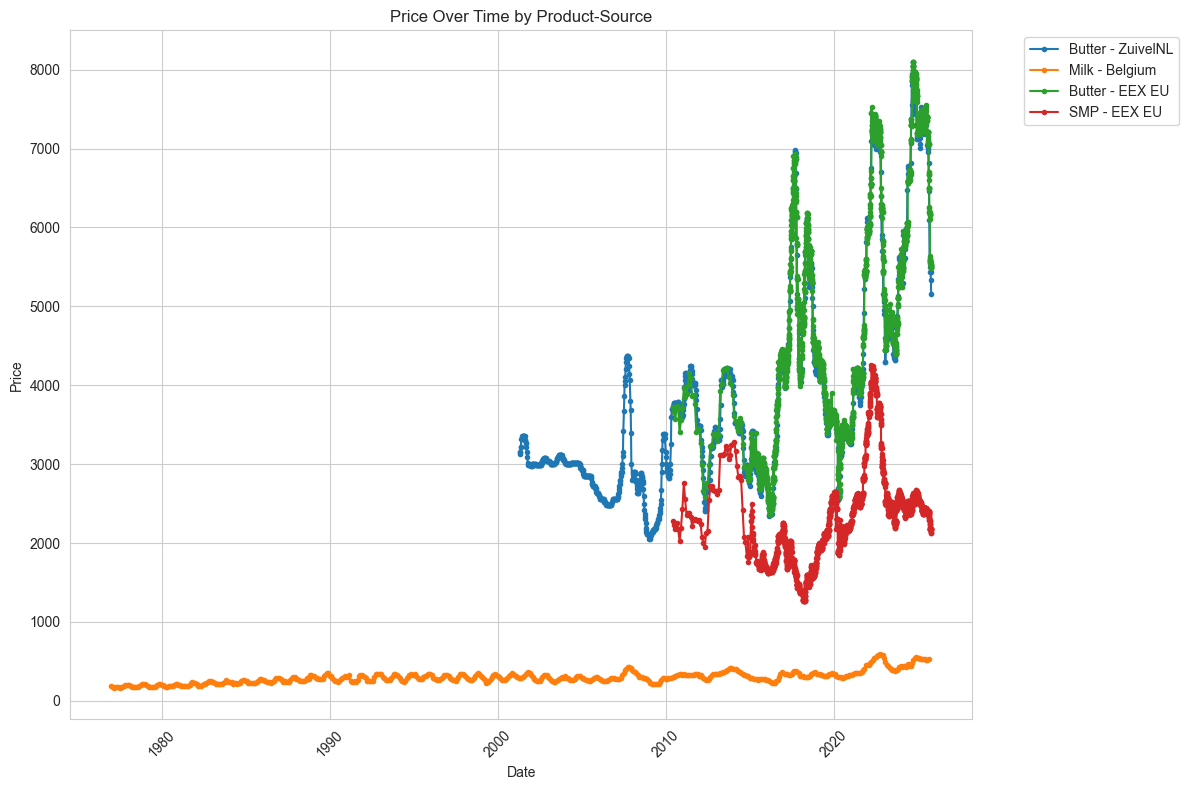

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the plot style
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# Create line plot for each ts_name
for ts_name in df['ts_name'].unique():
    subset = df[df['ts_name'] == ts_name]
    plt.plot(subset['date'], subset['price'], label=ts_name, marker='o', markersize=3)

plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Price Over Time by Product-Source')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
df.groupby('ts_name')['date'].count()

ts_name
Butter - EEX EU      2782
Butter - ZuivelNL    1221
Milk - Belgium        585
SMP - EEX EU         2756
Name: date, dtype: int64

In [22]:
df = df.sort_values(by=['ts_name', 'date'])
df['date_diff'] = df.groupby('ts_name')['date'].diff()
mean_date_diff = df.groupby('ts_name')['date_diff'].mean()
std_date_diff = df.groupby('ts_name')['date_diff'].std()
print(mean_date_diff)
print(std_date_diff)

ts_name
Butter - EEX EU      2 days 00:31:35.145631067
Butter - ZuivelNL    7 days 08:01:34.426229508
Milk - Belgium      30 days 10:28:46.027397260
SMP - EEX EU         2 days 00:59:03.811252268
Name: date_diff, dtype: timedelta64[ns]
ts_name
Butter - EEX EU     4 days 02:02:58.906162749
Butter - ZuivelNL   1 days 16:03:20.649567197
Milk - Belgium      0 days 19:37:15.016321050
SMP - EEX EU        4 days 04:02:07.469778045
Name: date_diff, dtype: timedelta64[ns]


In [ ]:
import requests

# Simple function to chat with the API
def chat_with_bot(message, thread_id=None):
    url = "http://localhost:8000/chat"
    data = {"message": message}
    
    if thread_id:
        data["thread_id"] = thread_id
    
    response = requests.post(url, json=data)
    
    if response.status_code == 200:
        result = response.json()
        print(f"Bot: {result['response']}")
        return result['thread_id']  # Return thread_id for next message
    else:
        print(f"Error: {response.text}")
        return None

# Usage examples:
thread_id = chat_with_bot("What is the price of butter from Belgium?")
thread_id = chat_with_bot("Compare the average prices of milk and butter this year", thread_id)





Bot: The price of butter from Belgium is not available in the database.
Bot: The average prices of milk and butter this year are as follows:
- Milk: €530.82
- Butter: €7058.43


'\nthread_id = chat_with_bot("What is the price of butter from Belgium?")\nthread_id = chat_with_bot("Compare the average prices of milk and butter this year", thread_id)\nthread_id = chat_with_bot("What about SMP from EEX EU?", thread_id)\nthread_id = chat_with_bot("Show me the volatility of milk prices", thread_id)\n'

In [ ]:
'''
thread_id = chat_with_bot("What is the price of butter from Belgium?")
thread_id = chat_with_bot("Compare the average prices of milk and butter this year", thread_id)
thread_id = chat_with_bot("What about SMP from EEX EU?", thread_id)
thread_id = chat_with_bot("Show me the volatility of milk prices", thread_id)
'''

In [55]:
thread_id = chat_with_bot("Has the trend for butter prices been bullish or bearish recently?", thread_id)

Bot: I couldn't retrieve recent data for butter prices in Belgium. Could you provide more specific information or a different timeframe for the analysis?
